# United States — F-Score grid study: basket k = 30, random draws = 1000

One cell of the reviewer-suggested 3 x 3 x 2 grid (basket sizes 20/25/30 x
random-sample sizes 1,000/2,000/5,000 x two markets). Signals come from
the team's FS_clean statements, scored by this repository's own signal code
(`fscore.signal.piotroski`, unit-tested, beginning-of-year asset scaling on
both sides of every delta); prices from the cached Yahoo data. Formations are
July 1 of **2012-2024** (13 chained holding years, each a full twelve
months) using score year T-1 — one conservative timing rule for both markets,
over identical calendar time so the two are comparable. July 2024 is the last
formation whose complete year finishes inside the sample.
Covariances are estimated on 36 months of daily returns ending the day
before formation. Note the panel resolves to *currently listed* symbols, so
the universe is survivorship-tilted — disclosed as a data limitation. The value control falls back to the universe
in years before B/M coverage begins (flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW
and plain universe minimum-variance controls; a dollar-neutral long-short
book (long top-k scores, short bottom-k, charged both legs' trading costs
plus a stock-borrow fee) wherever shorting is available — Vietnam runs
long-only, so `fscore_LS` is simply absent there; denoised
(not detoned) GMV;
primary measure fixed in advance = the GROSS Sharpe ratio (rf = 0), with
turnover and net-of-cost figures reported separately; and the synergy test
D = Sharpe(GMV) − Sharpe(EW) computed per basket. All figures are saved at dpi = 300.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.fs_clean import exclusion_report, load_scores
from fscore.data.team_scores import sectors_from_scores
from fscore.grid import run_grid
from fscore.plotting import setup_plots, save_fig

setup_plots()          # study-wide figure defaults; every saved chart is 300 dpi
MARKET, K, N_MC = "us", 30, 1000
YEARS = list(range(2012, 2025))
FIG = ROOT / "results" / "figures"
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)
TAG = "us_k30_mc1000"

scores = load_scores(MARKET, ROOT / "data")   # our own signal code
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)
study = run_grid(MARKET, scores, prices, sectors, YEARS, k=K, n_mc=N_MC,
                 n_gmv=300, seed=42)
diag = study.diagnostics()
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,tie_break_slots,overlap_random_vs_fscore,overlap_expected,cov_est_days,cov_min_est_days,delisted_in_holding_year,no_price_after_formation,long_short_run,short_leg_max_fscore
year,,,,,,,,,,,,,,,,,,
2012,69,6,61,30,False,30,10,6.101,6.0,7,0.436,0.435,756,378,0,0,True,6.0
2013,67,5,60,30,False,30,3,5.507,6.0,14,0.451,0.448,753,376,0,0,True,5.0
2014,70,3,64,30,False,30,11,6.114,7.0,19,0.429,0.429,752,376,0,0,True,6.0
2015,72,3,68,30,False,30,7,5.792,6.0,8,0.416,0.417,753,376,0,0,True,5.0
2016,67,3,64,30,False,30,10,5.881,6.0,6,0.449,0.448,756,378,0,0,True,6.0
2017,69,6,65,30,False,30,11,5.783,6.0,9,0.433,0.435,756,378,1,0,True,5.0
2018,73,6,70,30,False,30,8,5.904,6.0,7,0.415,0.411,755,377,0,1,True,6.0
2019,73,6,72,30,False,30,19,6.356,7.0,11,0.411,0.411,752,376,0,0,True,6.0
2020,74,3,73,30,False,30,9,5.689,6.0,10,0.405,0.405,754,377,0,0,True,5.0


### 0. Data discarded before any test

A firm-year enters the study only with a **complete nine-signal F-Score**.
Partial scores are dropped rather than summed over whatever is available —
an incomplete score is not a low score, and keeping them would push those
firms towards the bottom of the ranking and into the short leg.

Three things remove rows, counted separately because they mean different
things: an identifier that never resolved to a tradable symbol, a year with
no prior-year row to difference against, and a year whose nine signals were
not all computable. `dropped_no_price` in the diagnostics above counts the
further names removed for insufficient price history.

In [2]:
drops_total = exclusion_report(MARKET, ROOT / "data")
drops_year = exclusion_report(MARKET, ROOT / "data", by_year=True)
drops_total.to_csv(OUT / f"{TAG}_exclusions.csv")
r = drops_total.iloc[0]
print(f"{MARKET.upper()}: {int(r.rows_in_source)} firm-years in the source -> "
      f"{int(r.scored)} scored ({r.pct_scored:.1f}%)")
print(f"  identifier never resolved to a tradable symbol: {int(r.dropped_unresolved_identifier)}")
print(f"  no prior-year row to difference against:        {int(r.dropped_no_prior_year)}")
print(f"  nine signals not all computable:                {int(r.dropped_incomplete_signals)}")
drops_total

US: 2096 firm-years in the source -> 1739 scored (83.0%)
  identifier never resolved to a tradable symbol: 149
  no prior-year row to difference against:        208
  nine signals not all computable:                0


,rows_in_source,dropped_unresolved_identifier,dropped_incomplete_signals,scored,dropped_no_prior_year,pct_scored
us,2096.0,149.0,0.0,1739.0,208.0,82.97


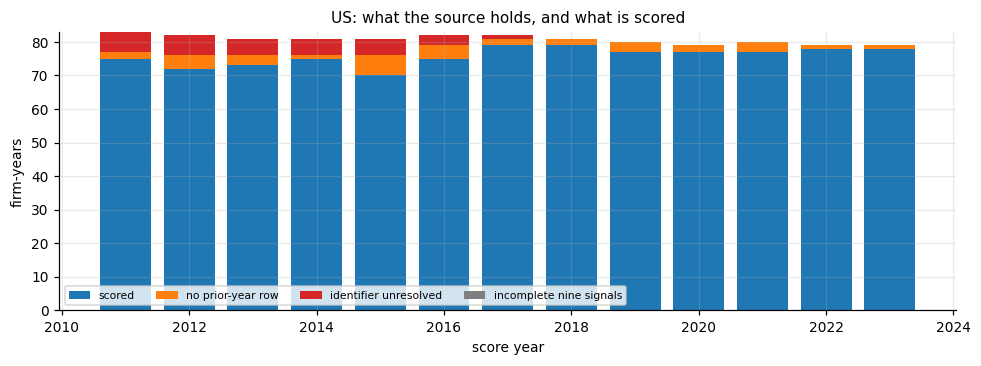

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.4))
b = drops_year.loc[[y - 1 for y in YEARS]]
ax.bar(b.index, b.scored, label="scored", color="tab:blue")
ax.bar(b.index, b.dropped_no_prior_year, bottom=b.scored,
       label="no prior-year row", color="tab:orange")
ax.bar(b.index, b.dropped_unresolved_identifier,
       bottom=b.scored + b.dropped_no_prior_year,
       label="identifier unresolved", color="tab:red")
ax.bar(b.index, b.dropped_incomplete_signals,
       bottom=b.scored + b.dropped_no_prior_year + b.dropped_unresolved_identifier,
       label="incomplete nine signals", color="tab:grey")
ax.set_xlabel("score year"); ax.set_ylabel("firm-years")
ax.set_title(f"{MARKET.upper()}: what the source holds, and what is scored")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
save_fig(f"{TAG}_exclusions", directory=FIG)
plt.show()

### 1. Summary (primary measure: **gross** Sharpe; rf = 0)

Gross performance is the cross-country convention — cost models differ by
market and would otherwise confound the comparison. Turnover is reported
beside it, and the net-of-cost columns follow as a sensitivity.

`nominal_k` is the basket size; `effective_n` is 1/Σw², the number of
holdings the weights actually amount to. They are not the same quantity: an
optimised or sector-capped book concentrates, so its effective N sits below
the names nominally held.

In [4]:
summary = study.summary()
summary[["ann_return", "ann_vol", "sharpe", "max_drawdown",
         "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.126,0.161,0.785,-0.379,30.0,30.000
fscore_GMV,0.094,0.150,0.627,-0.377,30.0,7.489
fscore_GMVsec,0.102,0.149,0.683,-0.370,30.0,9.199
fscore_high_EW,0.112,0.174,0.646,-0.399,10.0,10.846
value_EW,0.134,0.170,0.788,-0.367,30.0,30.000
universe_EW,0.134,0.159,0.840,-0.344,69.0,72.385
universe_GMV,0.074,0.146,0.511,-0.374,69.0,8.775
fscore_LS,-0.021,0.074,-0.280,-0.398,60.0,60.000


#### Turnover and the net-of-cost sensitivity (reported separately)

In [5]:
summary[["turnover", "cost_drag", "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.5917,0.0024,0.1236,0.7699
fscore_GMV,0.7796,0.0031,0.0907,0.6060
fscore_GMVsec,0.7818,0.0031,0.0984,0.6620
fscore_high_EW,0.8485,0.0034,0.1088,0.6264
value_EW,0.1444,0.0006,0.1331,0.7849
universe_EW,0.0425,0.0002,0.1337,0.8386
universe_GMV,0.3541,0.0014,0.0730,0.5014
fscore_LS,1.1639,0.0147,-0.0354,-0.4786


### 2. Yearly returns (each formation held July–June, a full twelve months)

In [6]:
yearly = study.yearly_returns()
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV,fscore_LS
date,,,,,,,,
2012,4.2,-2.5,-0.8,4.2,2.8,5.4,-0.9,-1.7
2013,32.3,16.5,23.0,25.5,30.4,32.8,12.9,-2.6
2014,16.0,18.2,15.3,16.5,12.7,13.4,17.2,4.3
2015,1.8,-0.3,4.2,-6.9,-6.9,-0.4,-2.9,6.7
2016,11.4,11.6,10.3,18.9,20.6,14.5,12.3,-5.7
2017,20.0,16.3,15.2,21.0,15.3,19.4,14.3,2.4
2018,-3.4,0.1,1.3,-7.1,-2.2,-3.6,-2.8,-2.0
2019,28.8,33.9,29.0,33.3,27.9,26.2,29.9,4.2
2020,6.6,-7.6,-3.9,5.0,11.1,14.8,-0.5,-9.5


### 3. Placement vs the random distributions

Reported gross and net of costs. The random control is redrawn every year, so
it carries its own turnover (~1 − k/|universe|) — charging both sides is the
like-for-like comparison; the gross rows show costs are not driving it.

Significance is judged at **one level fixed in advance: 5%** (`significant`
column = p < 0.05). There is no 1% or 10% tier: p = 0.06 is not
significant.

In [7]:
rows = {}
for pool, label in [("mc_ew", "random (full universe)"),
                    ("mc_nonf_ew", "random (non-F-Score names)")]:
    frame = getattr(study, pool)
    if frame.shape[1]:
        for stat in ["sharpe", "ann_return"]:
            for net in (False, True):
                basis = "net" if net else "gross"
                rows[(label, stat, basis)] = study.placement(
                    "fscore_EW", pool, stat, net=net)
placement = pd.DataFrame(rows).T
print(f"turnover — F-Score EW {study.strategy_turnover('fscore_EW'):.3f} "
      f"vs random basket {study.mc_turnover():.3f} (one-way, per year)")
placement.round(3)

turnover — F-Score EW 0.592 vs random basket 0.597 (one-way, per year)


percentile p_value significant  \
random (full universe)     sharpe     gross      0.304   0.696       False   
                                      net        0.303   0.697       False   
                           ann_return gross       0.23    0.77       False   
                                      net         0.23    0.77       False   
random (non-F-Score names) sharpe     gross      0.152   0.848       False   
                                      net        0.149   0.851       False   
                           ann_return gross      0.055   0.945       False   
                                      net        0.055   0.945       False   

                                            alpha n_draws random_mean  \
random (full universe)     sharpe     gross  0.05    1000    0.818711   
                                      net    0.05    1000    0.804016   
                           ann_return gross  0.05    1000    0.133049   
                                      net    0.05    1000     0.13066   
random (non-F-Score names) sharpe     gross  0.05    1000    0.834871   
                                      net    0.05    1000    0.820454   
                           ann_return gross  0.05    1000    0.138312   
                                      net    0.05    1000    0.135924   

                                            random_std    fscore  basis  
random (full universe)     sharpe     gross   0.065103  0.784654  gross  
                                      net     0.065004   0.76991    net  
                           ann_return gross   0.009932  0.125944  gross  
                                      net     0.009932  0.123577    net  
random (non-F-Score names) sharpe     gross   0.048066  0.784654  gross  
                                      net      0.04801   0.76991    net  
                           ann_return gross   0.007597  0.125944  gross  
                                      net     0.007597  0.123577    net

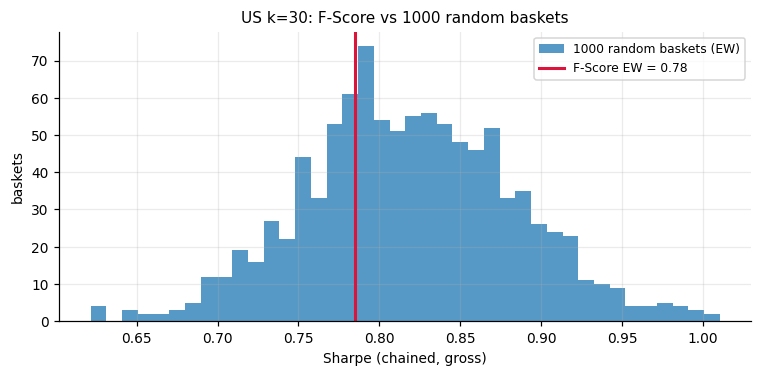

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sh = study.mc_metric(study.mc_ew, "sharpe")
ax.hist(sh, bins=40, alpha=0.75, label=f"{N_MC} random baskets (EW)")
# the placement index is (pool, statistic, basis); the histogram shows gross
fs = placement.loc[("random (full universe)", "sharpe", "gross"), "fscore"]
ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: F-Score vs {N_MC} random baskets")
plt.tight_layout()
save_fig(f"{TAG}_mc_hist", directory=FIG)
plt.show()

### 4. Synergy test: per-basket optimisation gain
D = Sharpe(GMV) − Sharpe(EW), judged at the 5% level.

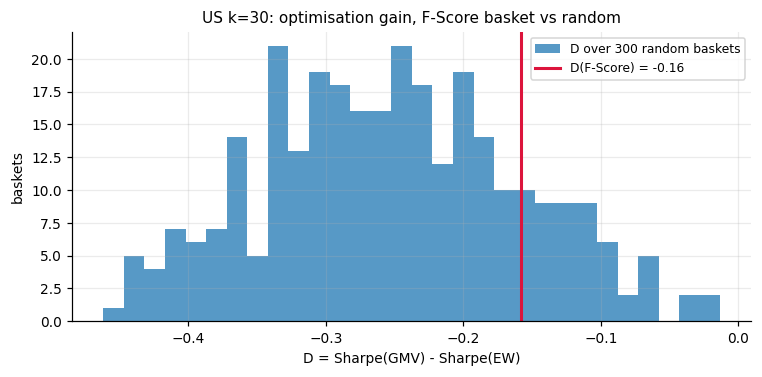

percentile       0.837
p_value          0.163
significant          0
alpha             0.05
n_draws            300
random_mean     -0.253
random_std       0.093
D_fscore        -0.158
D_random_mean   -0.253
D_random_std     0.093
n                  300
dtype: object

In [9]:
syn = study.synergy()
d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
          - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))], "sharpe")).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
ax.axvline(syn["D_fscore"], color="crimson", lw=2,
           label=f"D(F-Score) = {syn['D_fscore']:.2f}")
ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: optimisation gain, F-Score basket vs random")
plt.tight_layout()
save_fig(f"{TAG}_synergy_hist", directory=FIG)
plt.show()
pd.Series(syn).round(3)

### 5. Track record and outputs

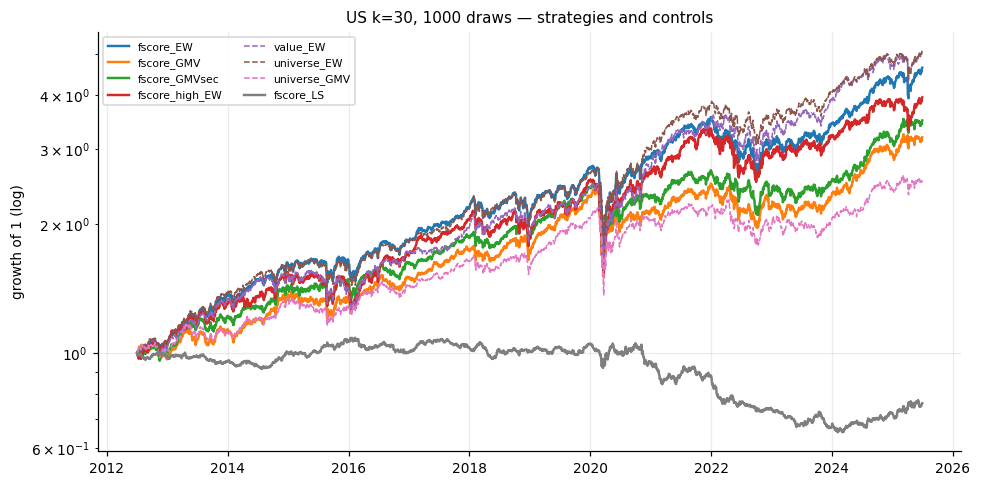

saved us_k30_mc1000


In [10]:
nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in nav.columns:
    ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
            ls="-" if c.startswith("fscore") else "--", label=c)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
ax.set_title(f"{MARKET.upper()} k={K}, {N_MC} draws — strategies and controls")
plt.tight_layout()
save_fig(f"{TAG}_nav", directory=FIG)
plt.show()

summary.to_csv(OUT / f"{TAG}_summary.csv")
placement.to_csv(OUT / f"{TAG}_placement.csv")
pd.Series(syn).to_frame("value").to_csv(OUT / f"{TAG}_synergy.csv")
yearly.to_csv(OUT / f"{TAG}_yearly_returns.csv")
diag.to_csv(OUT / f"{TAG}_diagnostics.csv")
print("saved", TAG)